In [68]:
# =========================================================
# TOPIC MODELLING PREPROCESSING
# =========================================================

# This preprocessing pipeline prepares YouTube comments
# for LDA topic modelling by:
# - cleaning noisy text
# - preserving important internet slang
# - removing low-information words
# - generating meaningful tokens and phrases
# - creating a document-term matri

In [69]:

# IMPORT LIBRARIES


import pandas as pd
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from gensim.models import Phrases
from gensim.models.phrases import Phraser

from sklearn.feature_extraction.text import CountVectorizer
from tqdm.notebook import tqdm




nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

tqdm.pandas()

print("Imports complete.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kreet\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kreet\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kreet\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kreet\AppData\Roaming\nltk_data...


Imports complete.


[nltk_data]   Package omw-1.4 is already up-to-date!


In [70]:
# LOAD CLEANED COMMENT DATA


df = pd.read_csv(r"D:\Social media Assignment 2\comments_cleaned.csv")

print(f"Loaded {len(df):,} comments")
df.head(2)


Loaded 6,241 comments


,video_id,video_title,author,comment_text,comment_published_at,comment_like_count,clean_comment,comment_length_chars,comment_length_words
0,laZpTO7IFtA,Is 67 just brain rot?,@ExoticNibbles2,Nothing makes me feel older then watching a 15...,2025-10-14T22:24:09Z,7902,nothing makes me feel older then watching a 15...,109,20
1,laZpTO7IFtA,Is 67 just brain rot?,@andrewbunnell7576,6 x 7 = 42 The answer to Life the Universe and...,2025-10-13T20:12:09Z,7692,6 x 7 = 42 the answer to life the universe and...,57,13


In [71]:
# LOAD DOMAIN-SPECIFIC SLANG VOCABULARY


# Slang terms discovered during exploratory NLP analysis
# are preserved during preprocessing so that important
# internet-native vocabulary is not accidentally removed.

slang_df = pd.read_csv("slang_candidates.csv")


In [72]:
DOMAIN_TERMS = set(
    slang_df[slang_df["frequency"] >= 5]["term"].str.lower()
)

REMOVE_TERMS = {
    "rowan", "wand", "josephine", "achina", "howtown",
    "kurzgesagt", "aevy"
}

DOMAIN_TERMS = DOMAIN_TERMS - REMOVE_TERMS

In [73]:
# CUSTOM STOPWORDS

# These are common filler words frequently found in
# YouTube comments but unlikely to help topic discovery.

CUSTOM_STOPWORDS = {

    # YouTube filler
    "video", "videos", "watch", "watching", "watched",
    "youtube", "channel", "comment", "comments",
    "subscribe", "subscribed",

    # Conversational filler
    "really", "actually", "basically", "literally",
    "honestly", "pretty", "quite", "maybe",
    "also", "still", "already", "always",
    "never", "ever", "okay", "yeah", "yes",
    "nah", "nope", "yep",

    # Casual internet filler
    "lol", "lmao", "haha", "hahaha",
    "omg", "bro", "dude",

    # Weak semantic verbs
    "get", "got", "getting",
    "know", "knowing",
    "think", "thinking",
    "make", "making", "made",
    "say", "said", "saying",
    "see", "seen",
    "come", "coming", "came",
    "use", "used", "using",

    # Weak nouns
    "thing", "things",
    "way", "time", "times",
    "lot", "many", "much",
    "something", "anything",
    "nothing", "everything",

    # Dataset-specific noise
    "thank", "thanks",
    "year", "years",
    "day", "days",
    "first", "well",
    "going", "would",
    "could", "should",

    # Broken contractions
    "im", "ive", "id",
    "dont", "didnt", "doesnt",
    "cant", "couldnt", "wouldnt",
    "wasnt", "isnt", "arent",
    "theyre", "youre", "thats",

    # Generic demographic terms
    "people",
}

In [74]:

MORE_STOPWORDS = {
    "like", "one", "good", "even", "want", "need",
    "back", "ago", "started", "start", "life",
    "old", "new", "much", "lot", "love", "better",
    "try", "someone", "thing", "stuff", "feel"
}

CUSTOM_STOPWORDS = CUSTOM_STOPWORDS | MORE_STOPWORDS

std_stopwords = set(stopwords.words("english"))

final_stopwords = (
    std_stopwords | CUSTOM_STOPWORDS
) - DOMAIN_TERMS

In [75]:
# INITIALIZE LEMMATIZER


lemmatizer = WordNetLemmatizer()

In [76]:

# PREPROCESSING FUNCTION
def preprocess_for_topic_model(text):

# Convert to lowercase
    text = str(text).lower()

# Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove timestamps like 4:22 or 1:05:30
    text = re.sub(
        r"\b\d{1,2}:\d{2}(:\d{2})?\b",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove standalone numbers
    text = re.sub(r"\b\d+\b", "", text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords while preserving
    # important domain slang
    cleaned_tokens = []

    for token in tokens:

        if token in DOMAIN_TERMS:
            cleaned_tokens.append(token)
            continue

        if token not in final_stopwords and len(token) >= 3:
            cleaned_tokens.append(token)

    # Lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in cleaned_tokens
    ]

    return cleaned_tokens


In [77]:
# APPLY PREPROCESSING


df["tokens"] = df["clean_comment"].progress_apply(
    preprocess_for_topic_model
)

print("Token preprocessing complete.")


  0%|          | 0/6241 [00:00<?, ?it/s]

Token preprocessing complete.


In [78]:

# REMOVE VERY SHORT COMMENTS


# Comments with very few meaningful words
# provide limited value for topic modelling.

before = len(df)

df = df[
    df["tokens"].apply(len) >= 5
].reset_index(drop=True)

after = len(df)

print(f"Removed {before - after:,} short comments")
print(f"Remaining comments: {after:,}")

Removed 2,252 short comments
Remaining comments: 3,989


In [79]:

# BIGRAM + TRIGRAM DETECTION


# Detect common multi-word phrases such as:
# - social_media
# - attention_span
# - short_form_content

bigram_model = Phrases(
    df["tokens"],
    min_count=5,
    threshold=10
)

trigram_model = Phrases(
    bigram_model[df["tokens"]],
    threshold=10
)

bigram_phraser = Phraser(bigram_model)
trigram_phraser = Phraser(trigram_model)

In [80]:
# APPLY N-GRAMS


def make_ngrams(tokens):

    bigrams = bigram_phraser[tokens]
    trigrams = trigram_phraser[bigrams]

    return trigrams


df["tokens"] = df["tokens"].progress_apply(
    make_ngrams
)

print("Bigrams and trigrams generated.")


  0%|          | 0/3989 [00:00<?, ?it/s]

Bigrams and trigrams generated.


In [81]:
# CREATE FINAL PROCESSED TEXT

df["processed_text"] = df["tokens"].apply(
    lambda tokens: " ".join(tokens)
)



# SANITY CHECK

all_tokens = [
    token
    for tokens in df["tokens"]
    for token in tokens
]

token_freq = Counter(all_tokens)

print("\nTop 50 most common tokens:\n")

for word, count in token_freq.most_common(50):
    print(f"{word:<25} {count}")




Top 50 most common tokens:

kid                       567
phone                     425
social_medium             299
word                      291
content                   237
parent                    236
work                      230
brain                     228
short                     226
gen                       223
internet                  221
brainrot                  220
brain_rot                 216
language                  208
slang                     192
keep                      182
child                     181
learning                  173
gen_alpha                 167
book                      167
screen                    164
thought                   163
great                     161
mean                      159
school                    155
learn                     152
real                      152
understand                150
since                     148
problem                   146
friend                    145
read                      145
long       

In [82]:
# CREATE DOCUMENT-TERM MATRIX


# CountVectorizer converts the processed text
# into a numerical word-frequency representation
# suitable for LDA topic modelling.

vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.85,
    max_features=2500
)

dtm = vectorizer.fit_transform(
    df["processed_text"]
)

vocab = vectorizer.get_feature_names_out()

print("\nDocument-Term Matrix Shape:")
print(dtm.shape)

print("\nSample Vocabulary:")
print(list(vocab[:50]))




Document-Term Matrix Shape:
(3989, 2451)

Sample Vocabulary:
['1960s', '1st', '2000s', '2010s', '30', '50', '60', '6th', '70', '80', '90', 'ability', 'ability_focus', 'able', 'absolute', 'absolutely', 'absorb', 'academic', 'accent', 'accept', 'access', 'accessible', 'account', 'accurate', 'achieve', 'acronym', 'across', 'act', 'acting', 'action', 'active', 'actively', 'activity', 'actual', 'ad', 'adam', 'add', 'added', 'addict', 'addicted', 'addicted_phone', 'addicted_social_medium', 'addicting', 'addiction', 'addictive', 'adding', 'addition', 'address', 'addressing', 'adhd']


In [83]:
# SAVE PREPROCESSED DATA


output_cols = [
    c for c in [
        "video_id",
        "video_title",
        "author",
        "comment_published_at",
        "comment_like_count"
    ]
    if c in df.columns
]

output_cols += [
    "tokens",
    "processed_text"
]

df[output_cols].to_csv(
    "topic_modelling_preprocessed.csv",
    index=False,
    encoding="utf-8"
)

print("\nSaved as topic_modelling_preprocessed.csv")



Saved as topic_modelling_preprocessed.csv


In [84]:
# EXAMPLE OUTPUT


print("\nExample Processed Comments:\n")

for i in range(3):

    print(f"\nCOMMENT {i+1}")
    print(df.loc[i, "processed_text"][:300])


Example Processed Comments:


COMMENT 1
make older minute breaking slang young kid

COMMENT 2
completely context thought solo version

COMMENT 3
linguistic equivalent somebody teardrop tattoo eye cause thought cute


In [85]:

# LDA TOPIC MODELLING


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from pprint import pprint





In [86]:
# LOAD PREPROCESSED DATA


df = pd.read_csv("topic_modelling_preprocessed.csv")

# Convert token strings back to lists if needed
# If tokens were saved as strings like "['word', 'word2']"
import ast

def safe_token_parse(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return str(x).split()

df["tokens"] = df["tokens"].apply(safe_token_parse)

print("Loaded preprocessed comments:", df.shape)
df.head()

Loaded preprocessed comments: (3989, 7)


,video_id,video_title,author,comment_published_at,comment_like_count,tokens,processed_text
0,laZpTO7IFtA,Is 67 just brain rot?,@ExoticNibbles2,2025-10-14T22:24:09Z,7902,"[make, older, minute, breaking, slang, young, ...",make older minute breaking slang young kid
1,laZpTO7IFtA,Is 67 just brain rot?,@codahighland,2025-12-10T16:03:28Z,121,"[completely, context, thought, solo, version]",completely context thought solo version
2,laZpTO7IFtA,Is 67 just brain rot?,@DisturbedNeo,2025-10-13T20:41:57Z,2882,"[linguistic, equivalent, somebody, teardrop, t...",linguistic equivalent somebody teardrop tattoo...
3,laZpTO7IFtA,Is 67 just brain rot?,@TheOneKnownAsKen,2025-12-30T18:03:29Z,29,"[switch, modification, semiautomatic, firearm,...",switch modification semiautomatic firearm full...
4,laZpTO7IFtA,Is 67 just brain rot?,@P010010010100101,2025-10-18T00:22:05Z,1429,"[whats, funnier, 🤣🤣🤣, spongebob, amount]",whats funnier 🤣🤣🤣 spongebob amount


In [87]:

# CREATE GENSIM DICTIONARY AND CORPUS


dictionary = corpora.Dictionary(df["tokens"])

# Remove very rare and overly common terms
dictionary.filter_extremes(
    no_below=5,
    no_above=0.85,
    keep_n=2500
)

corpus = [
    dictionary.doc2bow(tokens)
    for tokens in df["tokens"]
]

print("Number of documents:", len(corpus))
print("Number of unique terms:", len(dictionary))

Number of documents: 3989
Number of unique terms: 2442


In [88]:

# TEST DIFFERENT NUMBERS OF TOPICS


topic_range = range(3, 11)

coherence_scores = []
lda_models = {}

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=15,
        iterations=300,
        alpha="auto",
        eta="auto",
        per_word_topics=True
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df["tokens"],
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = coherence_model.get_coherence()

    coherence_scores.append(coherence)
    lda_models[num_topics] = lda_model

    print(f"Topics: {num_topics}, Coherence Score: {coherence:.4f}")

Topics: 3, Coherence Score: 0.3323
Topics: 4, Coherence Score: 0.3651
Topics: 5, Coherence Score: 0.3757
Topics: 6, Coherence Score: 0.3876
Topics: 7, Coherence Score: 0.3451
Topics: 8, Coherence Score: 0.3514
Topics: 9, Coherence Score: 0.2953
Topics: 10, Coherence Score: 0.3285


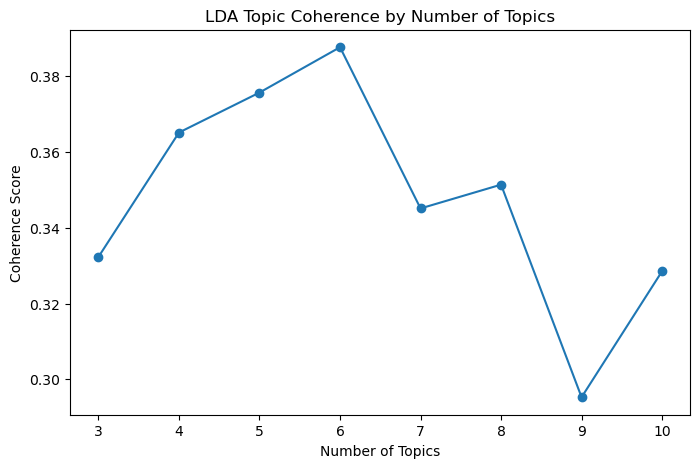

In [89]:
# PLOT COHERENCE SCORES


plt.figure(figsize=(8, 5))
plt.plot(list(topic_range), coherence_scores, marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("LDA Topic Coherence by Number of Topics")
plt.xticks(list(topic_range))
plt.show()

In [90]:
# SELECT BEST MODEL


best_num_topics = list(topic_range)[np.argmax(coherence_scores)]
best_lda_model = lda_models[best_num_topics]

print("Best number of topics:", best_num_topics)
print("Best coherence score:", max(coherence_scores))

Best number of topics: 6
Best coherence score: 0.3876381073936786


In [91]:

# DISPLAY TOP WORDS PER TOPIC


num_words = 12

topics_output = []

for topic_id in range(best_num_topics):
    words = best_lda_model.show_topic(topic_id, topn=num_words)

    topic_words = [word for word, weight in words]
    topic_weights = [weight for word, weight in words]

    topics_output.append({
        "topic_id": topic_id,
        "top_words": ", ".join(topic_words)
    })

    print(f"\nTopic {topic_id}")
    print(", ".join(topic_words))

topics_df = pd.DataFrame(topics_output)
topics_df


Topic 0
kid, phone, parent, short, social_medium, hour, screen, child, work, problem, internet, bad

Topic 1
gen, gen_alpha, understand, language, word, generation, slang, yeet, brain, born, english, brainrot

Topic 2
word, slang, mean, kid, meaning, heard, song, language, meme, gen, brain_rot, game

Topic 3
phone, focus, read, thought, brain, book, reading, attention, without, feeling, mind, minute

Topic 4
learning, learn, book, friend, kid, topic, work, language, english, school, brainrot, since

Topic 5
social_medium, content, phone, real, human, show, information, brain, internet, short, score, brain_rot


,topic_id,top_words
0,0,"kid, phone, parent, short, social_medium, hour..."
1,1,"gen, gen_alpha, understand, language, word, ge..."
2,2,"word, slang, mean, kid, meaning, heard, song, ..."
3,3,"phone, focus, read, thought, brain, book, read..."
4,4,"learning, learn, book, friend, kid, topic, wor..."
5,5,"social_medium, content, phone, real, human, sh..."


In [131]:
# =========================================================
# MANUALLY LABEL TOPICS
# =========================================================

# Labels based on the top keywords from the 6-topic LDA model

topic_labels = {
    0: "Children, screen time and social media concerns",

    1: "Gen Alpha slang and generational language",

    2: "Meme vocabulary and internet language meaning",

    3: "Attention span, reading and cognitive effects",

    4: "Learning, education and language development",

    5: "Digital content, internet culture and media criticism"
}

topics_df["topic_label"] = topics_df["topic_id"].map(topic_labels)

topics_df

,topic_id,top_words,topic_label
0,0,"kid, phone, parent, short, social_medium, hour...","Children, screen time and social media concerns"
1,1,"gen, gen_alpha, understand, language, word, ge...",Gen Alpha slang and generational language
2,2,"word, slang, mean, kid, meaning, heard, song, ...",Meme vocabulary and internet language meaning
3,3,"phone, focus, read, thought, brain, book, read...","Attention span, reading and cognitive effects"
4,4,"learning, learn, book, friend, kid, topic, wor...","Learning, education and language development"
5,5,"social_medium, content, phone, real, human, sh...","Digital content, internet culture and media cr..."


In [137]:

# ASSIGN DOMINANT TOPIC TO EACH COMMENT


def get_dominant_topic(bow):
    topic_probs = best_lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )

    dominant_topic = max(
        topic_probs,
        key=lambda x: x[1]
    )

    return dominant_topic[0], dominant_topic[1]


dominant_topics = [
    get_dominant_topic(bow)
    for bow in corpus
]

df["dominant_topic"] = [
    topic[0] for topic in dominant_topics
]

df["dominant_topic_probability"] = [
    topic[1] for topic in dominant_topics
]

df["topic_label"] = df["dominant_topic"].map(topic_labels)

df.head()

,video_id,video_title,author,comment_published_at,comment_like_count,tokens,processed_text,dominant_topic,dominant_topic_probability,topic_label
0,laZpTO7IFtA,Is 67 just brain rot?,@ExoticNibbles2,2025-10-14T22:24:09Z,7902,"[make, older, minute, breaking, slang, young, ...",make older minute breaking slang young kid,3,0.550814,"Attention span, reading and cognitive effects"
1,laZpTO7IFtA,Is 67 just brain rot?,@codahighland,2025-12-10T16:03:28Z,121,"[completely, context, thought, solo, version]",completely context thought solo version,1,0.894766,Gen Alpha slang and generational language
2,laZpTO7IFtA,Is 67 just brain rot?,@DisturbedNeo,2025-10-13T20:41:57Z,2882,"[linguistic, equivalent, somebody, teardrop, t...",linguistic equivalent somebody teardrop tattoo...,1,0.926795,Gen Alpha slang and generational language
3,laZpTO7IFtA,Is 67 just brain rot?,@TheOneKnownAsKen,2025-12-30T18:03:29Z,29,"[switch, modification, semiautomatic, firearm,...",switch modification semiautomatic firearm full...,3,0.828092,"Attention span, reading and cognitive effects"
4,laZpTO7IFtA,Is 67 just brain rot?,@P010010010100101,2025-10-18T00:22:05Z,1429,"[whats, funnier, 🤣🤣🤣, spongebob, amount]",whats funnier 🤣🤣🤣 spongebob amount,1,0.466176,Gen Alpha slang and generational language


In [139]:
# TOPIC DISTRIBUTION


topic_distribution = (
    df["topic_label"]
    .value_counts()
    .reset_index()
)

topic_distribution.columns = [
    "topic_label",
    "comment_count"
]

topic_distribution["percentage"] = (
    topic_distribution["comment_count"]
    / topic_distribution["comment_count"].sum()
    * 100
)

topic_distribution

,topic_label,comment_count,percentage
0,"Children, screen time and social media concerns",888,22.261218
1,Meme vocabulary and internet language meaning,741,18.576084
2,"Attention span, reading and cognitive effects",674,16.896465
3,"Learning, education and language development",575,14.414640
4,"Digital content, internet culture and media cr...",556,13.938330
5,Gen Alpha slang and generational language,555,13.913261


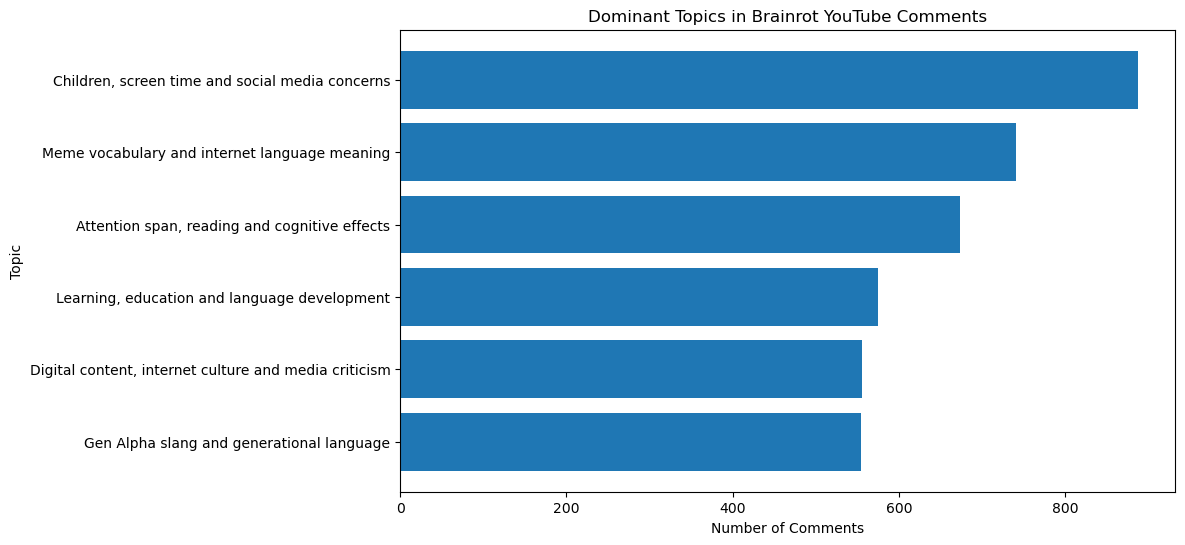

In [141]:

# VISUALISE TOPIC DISTRIBUTION


plt.figure(figsize=(10, 6))

plt.barh(
    topic_distribution["topic_label"],
    topic_distribution["comment_count"]
)

plt.xlabel("Number of Comments")
plt.ylabel("Topic")
plt.title("Dominant Topics in Brainrot YouTube Comments")
plt.gca().invert_yaxis()
plt.show()

In [143]:

# REPRESENTATIVE COMMENTS PER TOPIC


for topic in sorted(df["dominant_topic"].unique()):
    label = topic_labels.get(topic, "Unlabelled topic")

    print("\n" + "=" * 80)
    print(f"TOPIC {topic}: {label}")
    print("=" * 80)

    sample_comments = (
        df[df["dominant_topic"] == topic]
        .sort_values("dominant_topic_probability", ascending=False)
        .head(5)
    )

    for i, row in sample_comments.iterrows():
        print(f"\nProbability: {row['dominant_topic_probability']:.3f}")
        print(row["processed_text"][:500])


TOPIC 0: Children, screen time and social media concerns

Probability: 0.995
biggest issue limit social_medium restrict minute parent able extend hour restriction night weekday prevent child disturbed distracted social_medium disrupt learning activity next categorize child age_group social_medium minute old hour minute ultimately believe screen might contribute negative impact social_medium screen high prevents developing healthy habit social_medium limiting instead age give young possibility enjoy participate online learning express activity sure apps accessible limited

Probability: 0.993
teen grateful learned tiktok addictive popular nowadays tiktok short instagram_reel social_medium usage stayed last declined algorithm suck friend school triplearning camp finished everyone complained tired besides survive another camp immediately stay phone wayy le talkative introvert including bigger part family almost everyone sits phone person anyone_else play everyone prefers phone adult teena

In [97]:

# SAVE LDA RESULTS


topics_df.to_csv("lda_topics_top_words.csv", index=False)
topic_distribution.to_csv("lda_topic_distribution.csv", index=False)
df.to_csv("comments_with_lda_topics.csv", index=False)

print("Saved:")
print("- lda_topics_top_words.csv")
print("- lda_topic_distribution.csv")
print("- comments_with_lda_topics.csv")

Saved:
- lda_topics_top_words.csv
- lda_topic_distribution.csv
- comments_with_lda_topics.csv


In [145]:
from sklearn.manifold import TSNE
import numpy as np


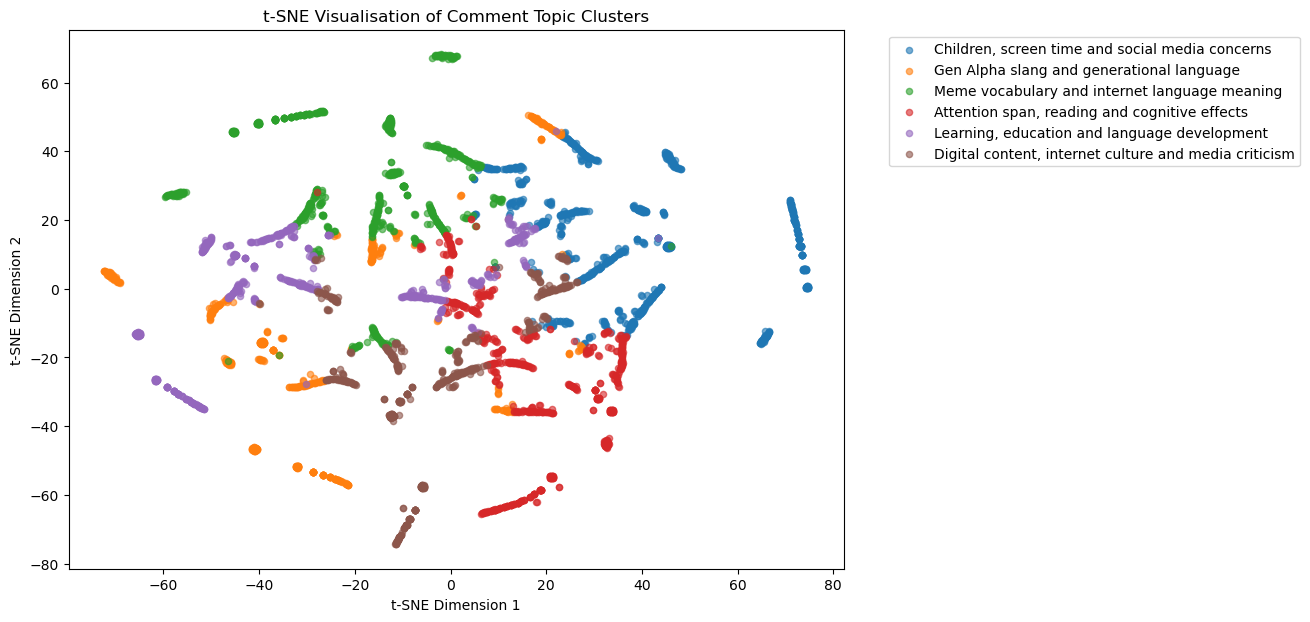

In [147]:

topic_vectors = []

for bow in corpus:
    topic_probs = best_lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )
    topic_vectors.append([prob for topic_id, prob in topic_probs])

topic_vectors = np.array(topic_vectors)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

tsne_results = tsne.fit_transform(topic_vectors)

df["tsne_x"] = tsne_results[:, 0]
df["tsne_y"] = tsne_results[:, 1]

plt.figure(figsize=(10, 7))

for topic_id in sorted(df["dominant_topic"].unique()):
    subset = df[df["dominant_topic"] == topic_id]
    plt.scatter(
        subset["tsne_x"],
        subset["tsne_y"],
        label=topic_labels[topic_id],
        alpha=0.6,
        s=20
    )

plt.title("t-SNE Visualisation of Comment Topic Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

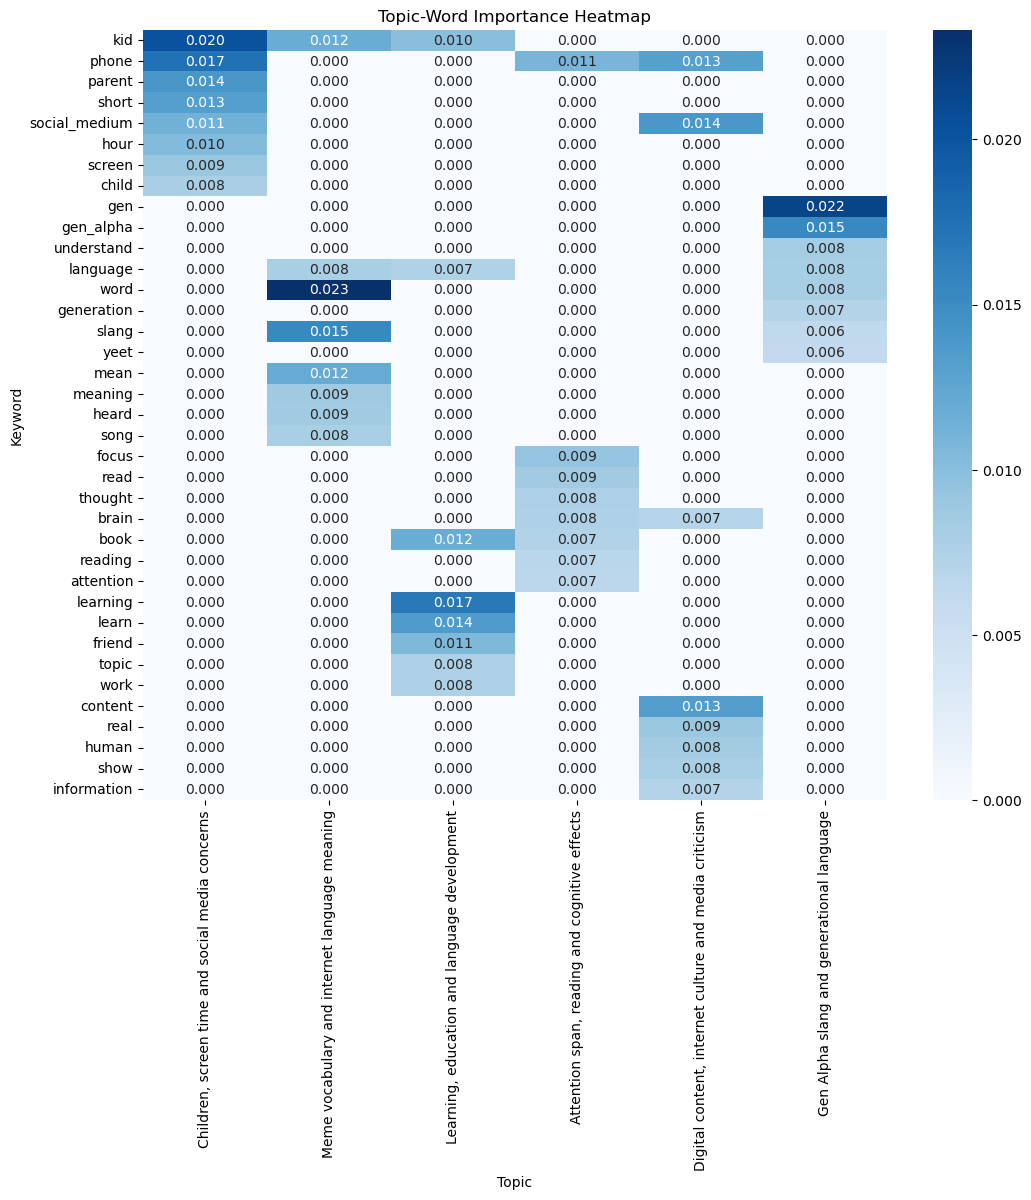

In [149]:
import seaborn as sns
import pandas as pd

top_n = 8

heatmap_data = {}

for topic_id in range(best_num_topics):
    words_weights = best_lda_model.show_topic(topic_id, topn=top_n)
    for word, weight in words_weights:
        heatmap_data.setdefault(word, {})
        heatmap_data[word][topic_labels[topic_id]] = weight

heatmap_df = pd.DataFrame(heatmap_data).T.fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="Blues")
plt.title("Topic-Word Importance Heatmap")
plt.xlabel("Topic")
plt.ylabel("Keyword")
plt.show()

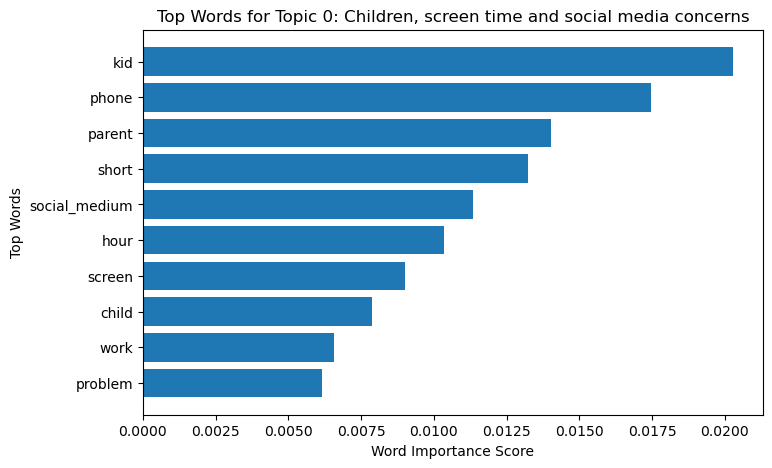

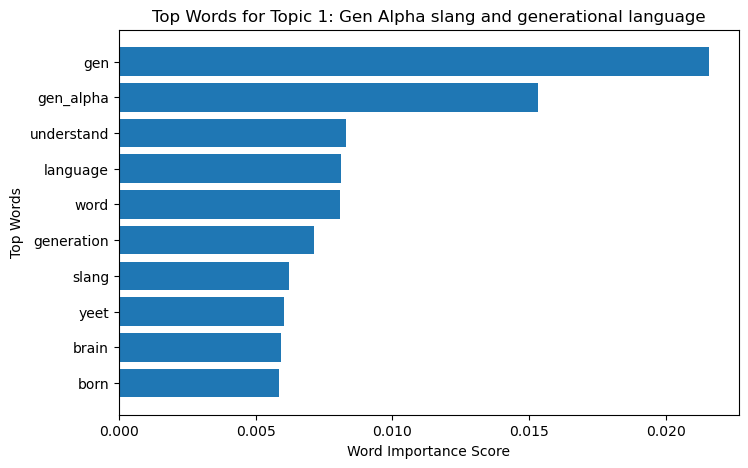

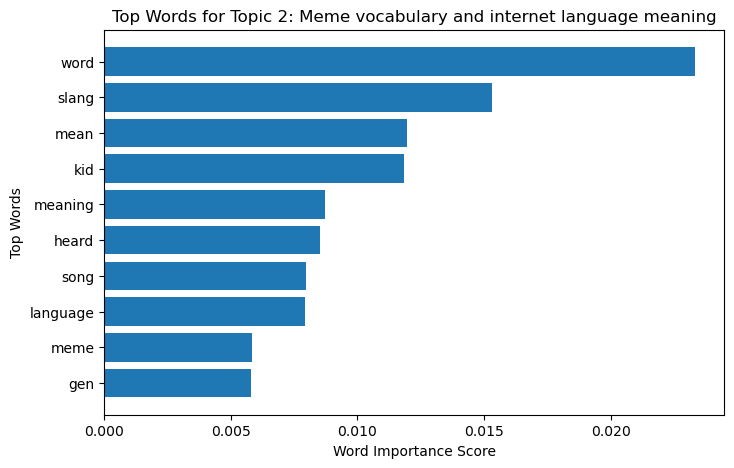

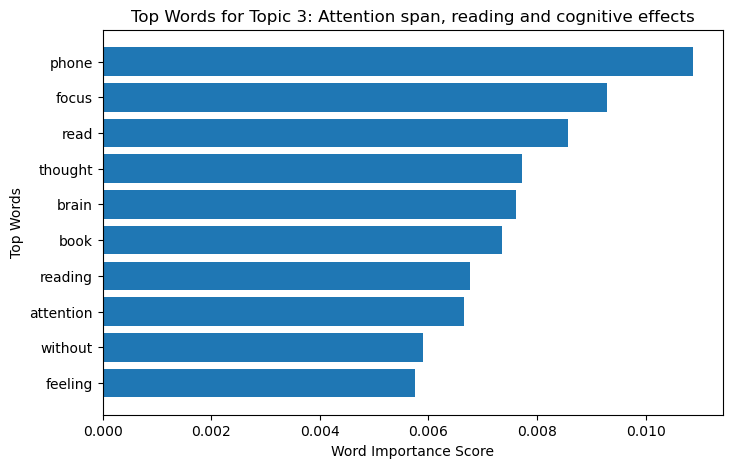

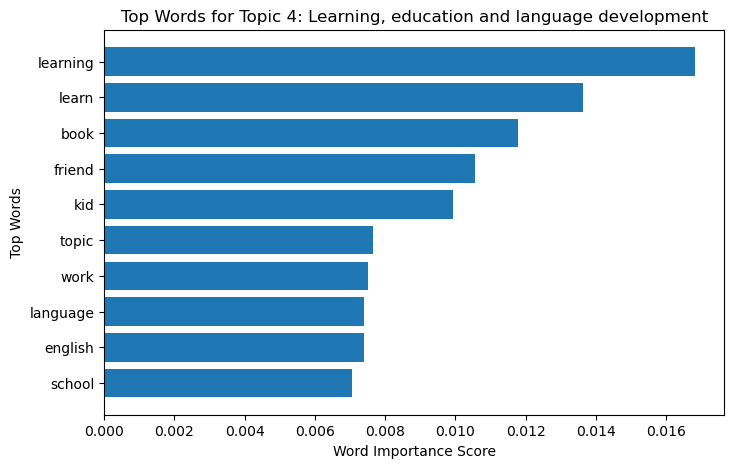

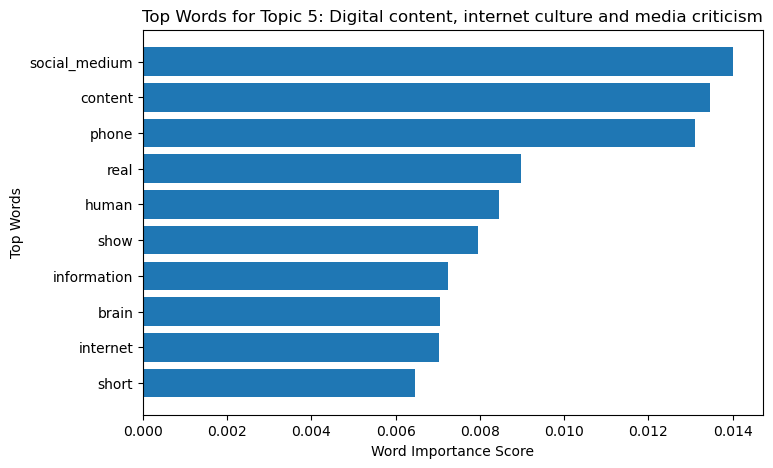

In [151]:
import matplotlib.pyplot as plt

num_words = 10

for topic_id in range(best_num_topics):
    topic_words = best_lda_model.show_topic(topic_id, topn=num_words)

    words = [word for word, weight in topic_words]
    weights = [weight for word, weight in topic_words]

    plt.figure(figsize=(8, 5))
    plt.barh(words, weights)
    plt.gca().invert_yaxis()
    plt.xlabel("Word Importance Score")
    plt.ylabel("Top Words")
    plt.title(f"Top Words for Topic {topic_id}: {topic_labels[topic_id]}")
    plt.show()

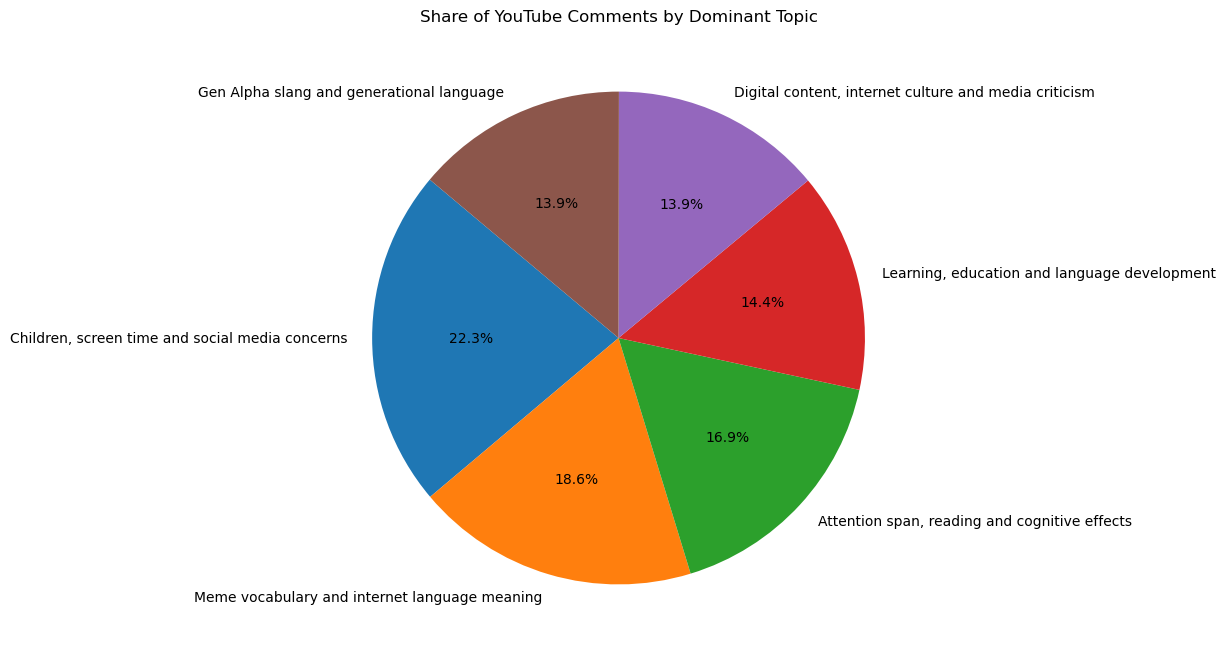

In [153]:
plt.figure(figsize=(8, 8))

plt.pie(
    topic_distribution["comment_count"],
    labels=topic_distribution["topic_label"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Share of YouTube Comments by Dominant Topic")
plt.show()